# 07 - Comparacao consolidada dos modelos finais

Este notebook consolida os resultados ja obtidos nos notebooks `05_random_forest_regressor_threshold_tuning.ipynb` e `06_xgboost_regressor_threshold_tuning.ipynb`.

Ele nao treina modelos, nao executa tuning, nao recarrega a ABT completa e nao recalcula predicoes. A comparacao usa apenas tabelas, metricas, hiperparametros e diagnosticos que ja ficaram materializados nos outputs dos notebooks finais.


In [21]:
from __future__ import annotations

import ast
import json
import math
import re
from html import unescape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "05_random_forest_regressor_threshold_tuning.ipynb").exists():
    NOTEBOOK_DIR = Path("ml/notebooks/02_modelos_finais")

NOTEBOOKS = {
    "Random Forest Regressor": NOTEBOOK_DIR / "05_random_forest_regressor_threshold_tuning.ipynb",
    "XGBoost Regressor": NOTEBOOK_DIR / "06_xgboost_regressor_threshold_tuning.ipynb",
}

for model, path in NOTEBOOKS.items():
    if not path.exists():
        raise FileNotFoundError(f"Notebook nao encontrado para {model}: {path}")


## Extracao dos resultados existentes

As funcoes abaixo leem os outputs HTML/stream dos notebooks `05` e `06`. Isso permite consolidar `baseline_summary`, candidatos avaliados, metricas por fold, metricas finais, hiperparametros campeoes e diagnosticos sem repetir o treinamento.


In [22]:
def _strip_tags(value: str) -> str:
    value = re.sub(r"<br\s*/?>", " ", value, flags=re.I)
    value = re.sub(r"<.*?>", "", value, flags=re.S)
    return unescape(value).strip()


def _convert_columns(df: pd.DataFrame) -> pd.DataFrame:
    converted = df.copy()
    for column in converted.columns:
        numeric = pd.to_numeric(converted[column], errors="coerce")
        if numeric.notna().sum() == converted[column].notna().sum() and converted[column].notna().any():
            converted[column] = numeric
    return converted


def _parse_html_tables(html: str) -> list[pd.DataFrame]:
    tables = []
    for block in re.findall(r"<table.*?</table>", html, flags=re.S | re.I):
        rows = []
        for tr in re.findall(r"<tr.*?</tr>", block, flags=re.S | re.I):
            cells = re.findall(r"<t[dh][^>]*>(.*?)</t[dh]>", tr, flags=re.S | re.I)
            if cells:
                rows.append([_strip_tags(cell) for cell in cells])
        if not rows:
            continue
        header = rows[0]
        data = rows[1:]
        if header and header[0] == "" and len(header) == 2:
            table = pd.DataFrame(
                [[row[0], row[1] if len(row) > 1 else None] for row in data],
                columns=["metric", "value"],
            )
        elif header and header[0] == "":
            table = pd.DataFrame([row[1:] for row in data], columns=header[1:])
        else:
            table = pd.DataFrame(data, columns=header)
        tables.append(_convert_columns(table))
    return tables


def _output_text(output: dict) -> str:
    parts = []
    text = output.get("text")
    if text:
        parts.append("".join(text) if isinstance(text, list) else str(text))
    data = output.get("data", {})
    for key in ["text/plain", "text/html"]:
        value = data.get(key)
        if value:
            parts.append("".join(value) if isinstance(value, list) else str(value))
    return "\n".join(parts)


def _extract_stream_objects(text: str) -> dict[str, object]:
    extracted: dict[str, object] = {}
    profile = re.search(r"Melhor perfil de peso:\s*(.+)", text)
    if profile:
        extracted["best_weight_profile_stream"] = profile.group(1).strip()
    params = re.search(r"Melhores hiperparametros:\s*(\{.*?\})(?:\n|$)", text, flags=re.S)
    if params:
        extracted["best_params_stream"] = ast.literal_eval(params.group(1))
    diagnosis = re.search(r"Diagnostico:\s*(\{.*?\})(?:\n|$)", text, flags=re.S)
    if diagnosis:
        extracted["fit_diagnosis_stream"] = ast.literal_eval(diagnosis.group(1))
    return extracted


def _metric_table_to_row(table: pd.DataFrame) -> dict[str, object]:
    row = {}
    for _, item in table.iterrows():
        key = str(item["metric"])
        value = item["value"]
        numeric = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
        row[key] = numeric if pd.notna(numeric) else value
    return row


def extract_notebook_results(model_name: str, notebook_path: Path) -> dict[str, object]:
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    html_tables: list[pd.DataFrame] = []
    text_outputs: list[str] = []

    for cell in notebook.get("cells", []):
        for output in cell.get("outputs", []):
            text_outputs.append(_output_text(output))
            html = output.get("data", {}).get("text/html")
            if html:
                html = "".join(html) if isinstance(html, list) else str(html)
                html_tables.extend(_parse_html_tables(html))

    baseline_summary = next(
        (table for table in html_tables if "baseline_cv_train_rmse_mean" in table.columns),
        pd.DataFrame(),
    )
    candidate_results = next(
        (table for table in html_tables if "candidate_index" in table.columns and "mean_validation_rmse" in table.columns),
        pd.DataFrame(),
    )
    fold_metrics = next(
        (table for table in html_tables if {"fold", "validation_rmse", "train_rmse"}.issubset(table.columns)),
        pd.DataFrame(),
    )
    final_metric_table = next(
        (table for table in html_tables if set(["metric", "value"]).issubset(table.columns) and table["metric"].eq("test_rmse").any()),
        pd.DataFrame(),
    )

    stream_objects: dict[str, object] = {}
    for text in text_outputs:
        stream_objects.update(_extract_stream_objects(text))

    final_metrics = _metric_table_to_row(final_metric_table) if not final_metric_table.empty else {}
    final_metrics.setdefault("model", model_name)
    final_metrics["source_notebook"] = notebook_path.name
    final_metrics.update(stream_objects)

    for table in [baseline_summary, candidate_results, fold_metrics]:
        if not table.empty:
            table.insert(0, "model", model_name)
            table.insert(1, "source_notebook", notebook_path.name)

    return {
        "baseline_summary": baseline_summary,
        "candidate_results": candidate_results,
        "fold_metrics": fold_metrics,
        "final_metrics": final_metrics,
        "final_metric_table": final_metric_table,
    }


extracted = {model: extract_notebook_results(model, path) for model, path in NOTEBOOKS.items()}

baseline_summary = pd.concat(
    [item["baseline_summary"] for item in extracted.values() if not item["baseline_summary"].empty],
    ignore_index=True,
)
candidate_results = pd.concat(
    [item["candidate_results"] for item in extracted.values() if not item["candidate_results"].empty],
    ignore_index=True,
)
fold_metrics = pd.concat(
    [item["fold_metrics"] for item in extracted.values() if not item["fold_metrics"].empty],
    ignore_index=True,
)
final_metrics = pd.DataFrame([item["final_metrics"] for item in extracted.values()])

summary_extraction = pd.DataFrame(
    [
        {
            "model": model,
            "source_notebook": item["final_metrics"].get("source_notebook"),
            "baseline_rows": len(item["baseline_summary"]),
            "candidate_rows_displayed": len(item["candidate_results"]),
            "fold_rows": len(item["fold_metrics"]),
            "final_metrics_found": bool(item["final_metrics"]),
        }
        for model, item in extracted.items()
    ]
)
summary_extraction


,model,source_notebook,baseline_rows,candidate_rows_displayed,fold_rows,final_metrics_found
0,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,1,12,3,True
1,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,1,15,3,True


## Desempenho consolidado

MSE e derivado de RMSE ao quadrado. MedAE, MAPE, sMAPE, Adjusted R² e Explained Variance nao aparecem nos outputs dos notebooks `05` e `06`; por isso ficam explicitamente marcados como nao disponiveis, sem novo calculo sobre dados brutos.


In [23]:
performance = final_metrics[[
    "model",
    "source_notebook",
    "train_rmse",
    "train_mae",
    "train_r2",
    "test_rmse",
    "test_mae",
    "test_r2",
    "best_cv_rmse",
    "best_cv_validation_rmse_mean",
    "best_cv_validation_rmse_std",
    "best_cv_validation_mae_mean",
    "best_cv_validation_r2_mean",
    "baseline_test_rmse",
    "test_rmse_gain_vs_baseline",
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "precision_macro",
    "recall_macro",
]].copy()

performance["test_mse_derived"] = performance["test_rmse"].astype(float) ** 2
performance["train_mse_derived"] = performance["train_rmse"].astype(float) ** 2
performance["rmse_over_mae_test"] = performance["test_rmse"].astype(float) / performance["test_mae"].astype(float)
performance = performance.sort_values(["test_rmse", "test_mae"], ascending=[True, True]).reset_index(drop=True)
performance.insert(0, "rank_test_rmse", performance.index + 1)
performance


,rank_test_rmse,model,source_notebook,train_rmse,train_mae,train_r2,test_rmse,test_mae,test_r2,best_cv_rmse,best_cv_validation_rmse_mean,best_cv_validation_rmse_std,best_cv_validation_mae_mean,best_cv_validation_r2_mean,baseline_test_rmse,test_rmse_gain_vs_baseline,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,test_mse_derived,train_mse_derived,rmse_over_mae_test
0,1,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,0.039623,0.030216,0.850710,0.045343,0.034145,0.801977,0.053637,0.053637,0.002257,0.037847,0.730599,0.046108,0.000764,0.998921,0.997761,0.997949,0.998136,0.997761,0.002056,0.001570,1.327954
1,2,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,0.047679,0.035262,0.783838,0.046962,0.035402,0.787586,0.054655,0.054655,0.002136,0.038990,0.720535,0.051662,0.004700,0.998165,0.997126,0.996518,0.995913,0.997126,0.002205,0.002273,1.326535


In [24]:
requested_metric_coverage = pd.DataFrame(
    [
        {"metric": "MAE", "status": "disponivel", "column": "test_mae", "note": "Logado nos notebooks finais."},
        {"metric": "MSE", "status": "derivado", "column": "test_mse_derived", "note": "Derivado de test_rmse ** 2."},
        {"metric": "RMSE", "status": "disponivel", "column": "test_rmse", "note": "Logado nos notebooks finais."},
        {"metric": "MedAE", "status": "nao_disponivel", "column": "", "note": "Nao aparece nos outputs dos notebooks 05/06."},
        {"metric": "MAPE", "status": "nao_disponivel", "column": "", "note": "Nao aparece nos outputs dos notebooks 05/06."},
        {"metric": "sMAPE", "status": "nao_disponivel", "column": "", "note": "Nao aparece nos outputs dos notebooks 05/06."},
        {"metric": "R2", "status": "disponivel", "column": "test_r2", "note": "Logado nos notebooks finais."},
        {"metric": "Adjusted R2", "status": "nao_disponivel", "column": "", "note": "Nao ha n/p efetivo nos outputs para calcular sem reprocessar o pipeline."},
        {"metric": "Explained Variance", "status": "nao_disponivel", "column": "", "note": "Nao aparece nos outputs dos notebooks 05/06."},
    ]
)
requested_metric_coverage


,metric,status,column,note
0,MAE,disponivel,test_mae,Logado nos notebooks finais.
1,MSE,derivado,test_mse_derived,Derivado de test_rmse ** 2.
2,RMSE,disponivel,test_rmse,Logado nos notebooks finais.
3,MedAE,nao_disponivel,,Nao aparece nos outputs dos notebooks 05/06.
4,MAPE,nao_disponivel,,Nao aparece nos outputs dos notebooks 05/06.
5,sMAPE,nao_disponivel,,Nao aparece nos outputs dos notebooks 05/06.
6,R2,disponivel,test_r2,Logado nos notebooks finais.
7,Adjusted R2,nao_disponivel,,Nao ha n/p efetivo nos outputs para calcular sem reprocessar o pipeline.
8,Explained Variance,nao_disponivel,,Nao aparece nos outputs dos notebooks 05/06.


## Generalizacao e estabilidade

Os notebooks finais usaram `TimeSeriesSplit` com 3 folds, nao KFold 5/10. A consolidacao abaixo respeita exatamente o que foi executado e calcula media, desvio padrao, intervalo de confianca de 95% e coeficiente de variacao sobre os folds ja materializados.


In [25]:
def summarize_fold_metric(values: pd.Series) -> dict[str, float]:
    values = values.astype(float).dropna()
    n = len(values)
    mean = float(values.mean()) if n else np.nan
    std = float(values.std(ddof=1)) if n > 1 else 0.0
    margin = float(stats.t.ppf(0.975, n - 1) * std / math.sqrt(n)) if n > 1 else np.nan
    return {
        "n_folds": n,
        "mean": mean,
        "std": std,
        "ci95_low": mean - margin if n > 1 else np.nan,
        "ci95_high": mean + margin if n > 1 else np.nan,
        "ci95_margin": margin,
        "coefficient_variation": float(std / abs(mean)) if mean else np.nan,
    }

fold_metric_columns = ["train_rmse", "validation_rmse", "train_mae", "validation_mae", "train_r2", "validation_r2"]
generalization_rows = []
for (model, source), group in fold_metrics.groupby(["model", "source_notebook"]):
    for metric in fold_metric_columns:
        row = {
            "model": model,
            "source_notebook": source,
            "cv_strategy_available": "TimeSeriesSplit(k=3)",
            "metric": metric,
        }
        row.update(summarize_fold_metric(group[metric]))
        generalization_rows.append(row)

generalization_summary = pd.DataFrame(generalization_rows)
generalization_summary.sort_values(["metric", "mean"]).reset_index(drop=True)


,model,source_notebook,cv_strategy_available,metric,n_folds,mean,std,ci95_low,ci95_high,ci95_margin,coefficient_variation
0,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),train_mae,3,0.029268,0.000674,0.027594,0.030941,0.001673,0.023013
1,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),train_mae,3,0.036111,0.000562,0.034714,0.037508,0.001397,0.015569
2,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),train_r2,3,0.767577,0.013611,0.733766,0.801388,0.033811,0.017732
3,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),train_r2,3,0.855177,0.001503,0.851444,0.858911,0.003733,0.001757
4,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),train_rmse,3,0.038526,0.000625,0.036973,0.040079,0.001553,0.016228
5,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),train_rmse,3,0.048777,0.000665,0.047126,0.050428,0.001651,0.013625
6,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),validation_mae,3,0.037847,0.001881,0.033175,0.042518,0.004672,0.049689
7,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),validation_mae,3,0.038990,0.001401,0.035511,0.042470,0.003480,0.035926
8,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),validation_r2,3,0.720535,0.016764,0.678890,0.762180,0.041645,0.023266
9,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),validation_r2,3,0.730598,0.022983,0.673506,0.787691,0.057093,0.031458


In [26]:
stability = generalization_summary.query("metric == 'validation_rmse'").copy()
stability["stability_label"] = pd.cut(
    stability["coefficient_variation"],
    bins=[-np.inf, 0.05, 0.10, np.inf],
    labels=["alta", "moderada", "baixa"],
)
stability = stability.sort_values(["mean", "coefficient_variation"]).reset_index(drop=True)
stability


,model,source_notebook,cv_strategy_available,metric,n_folds,mean,std,ci95_low,ci95_high,ci95_margin,coefficient_variation,stability_label
0,Random Forest Regressor,05_random_forest_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),validation_rmse,3,0.053637,0.002765,0.046769,0.060505,0.006868,0.051545,moderada
1,XGBoost Regressor,06_xgboost_regressor_threshold_tuning.ipynb,TimeSeriesSplit(k=3),validation_rmse,3,0.054655,0.002616,0.048156,0.061155,0.006499,0.047870,alta


## Overfitting e underfitting

A comparacao usa os gaps ja calculados pelos notebooks finais e tambem o gap medio entre treino e validacao nos folds exibidos.


In [27]:
overfit = final_metrics[[
    "model",
    "train_rmse",
    "best_cv_validation_rmse_mean",
    "test_rmse",
    "train_validation_rmse_gap",
    "train_validation_rmse_gap_ratio",
    "fit_status",
    "fit_explanation",
]].copy()

gap_by_fold = (
    fold_metrics.assign(validation_train_rmse_gap=lambda df: df["validation_rmse"] - df["train_rmse"])
    .groupby("model", as_index=False)
    .agg(
        fold_gap_rmse_mean=("validation_train_rmse_gap", "mean"),
        fold_gap_rmse_std=("validation_train_rmse_gap", "std"),
    )
)

overfit = overfit.merge(gap_by_fold, on="model", how="left")
overfit.sort_values("train_validation_rmse_gap_ratio", ascending=False).reset_index(drop=True)


,model,train_rmse,best_cv_validation_rmse_mean,test_rmse,train_validation_rmse_gap,train_validation_rmse_gap_ratio,fit_status,fit_explanation,fold_gap_rmse_mean,fold_gap_rmse_std
0,Random Forest Regressor,0.039623,0.053637,0.045343,0.014014,0.353693,adequate,Nao ha sinal forte de sobreajuste/subajuste no...,0.015112,0.003291
1,XGBoost Regressor,0.047679,0.054655,0.046962,0.006977,0.146332,adequate,Nao ha sinal forte de sobreajuste/subajuste no...,0.005878,0.001997


## Complexidade disponivel

Os outputs dos notebooks finais mostram os hiperparametros campeoes, mas nao trazem numero real de nos, folhas, profundidade efetiva por arvore, uso de RAM/CPU ou tamanho do artefato. A tabela abaixo consolida o que esta disponivel e marca o restante como nao disponivel.


In [28]:
def params_for(model: str) -> dict[str, object]:
    params = final_metrics.loc[final_metrics["model"].eq(model), "best_params_stream"]
    if params.empty or not isinstance(params.iloc[0], dict):
        return {}
    return {key.replace("model__", ""): value for key, value in params.iloc[0].items()}

complexity_rows = []
for model in final_metrics["model"]:
    params = params_for(model)
    n_estimators = params.get("n_estimators", np.nan)
    max_depth = params.get("max_depth", np.nan)
    proxy = n_estimators * max_depth if pd.notna(n_estimators) and pd.notna(max_depth) else np.nan
    complexity_rows.append(
        {
            "model": model,
            "n_estimators": n_estimators,
            "max_depth_configured": max_depth,
            "complexity_proxy_estimators_x_depth": proxy,
            "max_features_or_colsample": params.get("max_features", params.get("colsample_bytree", np.nan)),
            "min_samples_leaf": params.get("min_samples_leaf", np.nan),
            "min_samples_split": params.get("min_samples_split", np.nan),
            "learning_rate": params.get("learning_rate", np.nan),
            "reg_alpha": params.get("reg_alpha", np.nan),
            "reg_lambda": params.get("reg_lambda", np.nan),
            "tree_nodes": "nao_disponivel_nos_outputs",
            "tree_leaves": "nao_disponivel_nos_outputs",
            "model_size_mb": "nao_disponivel_nos_outputs",
            "cpu_ram_training": "nao_disponivel_nos_outputs",
        }
    )
complexity = pd.DataFrame(complexity_rows).sort_values("complexity_proxy_estimators_x_depth").reset_index(drop=True)
complexity


,model,n_estimators,max_depth_configured,complexity_proxy_estimators_x_depth,max_features_or_colsample,min_samples_leaf,min_samples_split,learning_rate,reg_alpha,reg_lambda,tree_nodes,tree_leaves,model_size_mb,cpu_ram_training
0,XGBoost Regressor,260,4,1040,0.85,NaN,NaN,0.08,0.1,2.0,nao_disponivel_nos_outputs,nao_disponivel_nos_outputs,nao_disponivel_nos_outputs,nao_disponivel_nos_outputs
1,Random Forest Regressor,120,14,1680,0.80,8.0,10.0,NaN,NaN,NaN,nao_disponivel_nos_outputs,nao_disponivel_nos_outputs,nao_disponivel_nos_outputs,nao_disponivel_nos_outputs


## Robustez a outliers e residuos

Sem a tabela de predicoes/residuos nos outputs do `05`/`06`, a consolidacao numerica possivel e a diferenca entre RMSE e MAE. Os graficos de residuos ja existem nos notebooks de origem, mas os residuos individuais nao foram materializados em tabela neste notebook.


In [29]:
robustness = performance[["model", "test_rmse", "test_mae", "rmse_over_mae_test"]].copy()
robustness["rmse_minus_mae_test"] = robustness["test_rmse"] - robustness["test_mae"]
robustness["outlier_sensitivity_reading"] = np.where(
    robustness["rmse_over_mae_test"] <= 1.35,
    "baixa_a_moderada_pelos_indicadores_disponiveis",
    "maior_sensibilidade_pelos_indicadores_disponiveis",
)
robustness.sort_values("rmse_over_mae_test").reset_index(drop=True)


,model,test_rmse,test_mae,rmse_over_mae_test,rmse_minus_mae_test,outlier_sensitivity_reading
0,XGBoost Regressor,0.046962,0.035402,1.326535,0.011560,baixa_a_moderada_pelos_indicadores_disponiveis
1,Random Forest Regressor,0.045343,0.034145,1.327954,0.011198,baixa_a_moderada_pelos_indicadores_disponiveis


## Interpretabilidade e eficiencia computacional

Importancia de variaveis, permutation importance, SHAP, PDP, interacoes, tempos, CPU e RAM nao foram materializados nos outputs dos notebooks `05` e `06`. Mantemos esses itens no relatorio como lacunas, em vez de gerar uma nova avaliacao.


In [30]:
not_available_items = pd.DataFrame(
    [
        {"area": "Eficiencia computacional", "item": "tempo de treinamento", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Eficiencia computacional", "item": "tempo de predicao", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Eficiencia computacional", "item": "CPU media/maxima", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Eficiencia computacional", "item": "RAM consumida", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Interpretabilidade", "item": "importancia das variaveis", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Interpretabilidade", "item": "permutation importance", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Interpretabilidade", "item": "SHAP values", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Interpretabilidade", "item": "PDP", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Interpretabilidade", "item": "feature interaction analysis", "status": "nao_disponivel_nos_outputs_05_06"},
        {"area": "Residuos", "item": "histograma/boxplot/QQ/residuos vs previsto/real", "status": "graficos_existem_nos_notebooks_05_06_sem_tabela_de_residuos"},
        {"area": "Classificacao", "item": "ROC/AUC/PR/calibracao/log loss/Brier", "status": "nao_aplicavel_modelos_finais_sao_regressores_sem_probabilidade"},
    ]
)
not_available_items


,area,item,status
0,Eficiencia computacional,tempo de treinamento,nao_disponivel_nos_outputs_05_06
1,Eficiencia computacional,tempo de predicao,nao_disponivel_nos_outputs_05_06
2,Eficiencia computacional,CPU media/maxima,nao_disponivel_nos_outputs_05_06
3,Eficiencia computacional,RAM consumida,nao_disponivel_nos_outputs_05_06
4,Interpretabilidade,importancia das variaveis,nao_disponivel_nos_outputs_05_06
5,Interpretabilidade,permutation importance,nao_disponivel_nos_outputs_05_06
6,Interpretabilidade,SHAP values,nao_disponivel_nos_outputs_05_06
7,Interpretabilidade,PDP,nao_disponivel_nos_outputs_05_06
8,Interpretabilidade,feature interaction analysis,nao_disponivel_nos_outputs_05_06
9,Residuos,histograma/boxplot/QQ/residuos vs previsto/real,graficos_existem_nos_notebooks_05_06_sem_tabela_de_residuos


## Criticidade prevista por modelo

Os notebooks finais registraram as taxas previstas de `OK` e `Alerta de compra`. Aqui consolidamos essas proporcoes por modelo. Quando os artefatos de predicoes do MLflow estiverem acessiveis, tambem mostramos contagens absolutas e exemplos de linhas previstas como criticas/alerta e nao criticas.


In [31]:
criticality_rates = final_metrics[[
    "model",
    "taxa_ok",
    "taxa_alerta_compra",
    "taxa_necessita_compra",
]].copy()

criticality_rates_long = criticality_rates.melt(
    id_vars="model",
    value_vars=["taxa_ok", "taxa_alerta_compra"],
    var_name="classe_predita",
    value_name="taxa",
)
criticality_rates_long["classe_predita"] = criticality_rates_long["classe_predita"].map(
    {
        "taxa_ok": "Nao critica / OK",
        "taxa_alerta_compra": "Critica / Alerta de compra",
    }
)
criticality_rates_long["percentual"] = criticality_rates_long["taxa"].astype(float) * 100
criticality_rates_long.sort_values(["model", "classe_predita"]).reset_index(drop=True)


,model,classe_predita,taxa,percentual
0,Random Forest Regressor,Critica / Alerta de compra,0.155719,15.5719
1,Random Forest Regressor,Nao critica / OK,0.844281,84.4281
2,XGBoost Regressor,Critica / Alerta de compra,0.156331,15.6331
3,XGBoost Regressor,Nao critica / OK,0.843669,84.3669


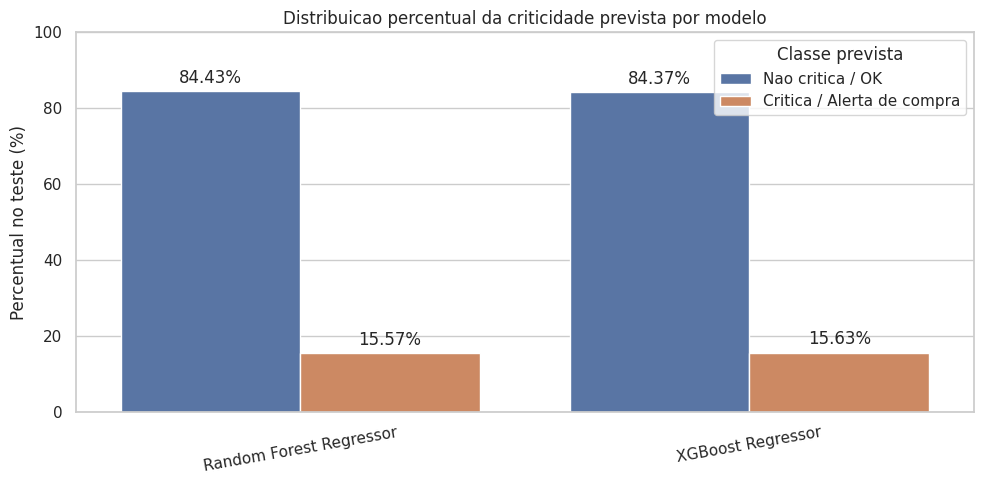

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=criticality_rates_long,
    x="model",
    y="percentual",
    hue="classe_predita",
    ax=ax,
)
ax.set_title("Distribuicao percentual da criticidade prevista por modelo")
ax.set_xlabel("")
ax.set_ylabel("Percentual no teste (%)")
ax.set_ylim(0, max(100, criticality_rates_long["percentual"].max() * 1.12))
ax.tick_params(axis="x", rotation=10)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)
ax.legend(title="Classe prevista")
fig.tight_layout()
plt.show()


### Exemplos das linhas previstas

A celula abaixo nao recalcula previsoes. Ela tenta recuperar os CSVs de predicao ja registrados pelos notebooks `05` e `06` no MLflow, usando `run_id` e `prediction_artifact_path` extraidos dos outputs desses notebooks. Se o MLflow nao estiver disponivel nesta sessao, a tabela de exemplos fica vazia e o aviso explica o motivo.


In [33]:
from io import StringIO
import os
import socket
from urllib.parse import urlparse


def _slugify_artifact(value: str) -> str:
    value = value.lower().strip()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    return value.strip("_")


def _prediction_artifact_path(row: pd.Series) -> str:
    artifact_path = row.get("prediction_artifact_path", "")
    if isinstance(artifact_path, str) and artifact_path and "..." not in artifact_path:
        return artifact_path
    source_notebook = str(row.get("source_notebook", "")).replace(".ipynb", "")
    model_slug = _slugify_artifact(str(row.get("model", "")))
    return f"evaluation/{source_notebook}_{model_slug}_threshold_regression_predictions.csv"


def _tracking_uri_available(uri: str, timeout_s: float = 0.75) -> tuple[bool, str]:
    parsed = urlparse(uri)
    if parsed.scheme in {"", "file"}:
        return True, "local_file_store"
    if parsed.scheme not in {"http", "https"}:
        return False, f"scheme_nao_suportado:{parsed.scheme}"
    host = parsed.hostname
    port = parsed.port or (443 if parsed.scheme == "https" else 80)
    if not host:
        return False, "host_ausente"
    try:
        with socket.create_connection((host, port), timeout=timeout_s):
            return True, f"conexao_ok:{host}:{port}"
    except OSError as exc:
        return False, f"sem_conexao:{host}:{port} ({exc})"


def load_logged_predictions(final_metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    notices = []
    frames = []
    try:
        import mlflow
    except ImportError as exc:
        return pd.DataFrame(), pd.DataFrame([
            {
                "status": "mlflow_indisponivel",
                "detail": f"MLflow nao esta instalado neste ambiente: {exc}",
            }
        ])

    tracking_uri = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000")
    available, availability_detail = _tracking_uri_available(tracking_uri)
    if not available:
        return pd.DataFrame(), pd.DataFrame([
            {
                "status": "mlflow_tracking_uri_inacessivel",
                "tracking_uri": tracking_uri,
                "detail": availability_detail,
            }
        ])

    mlflow.set_tracking_uri(tracking_uri)
    for _, row in final_metrics.iterrows():
        model = row.get("model", "")
        run_id = row.get("run_id", "")
        artifact_path = _prediction_artifact_path(row)
        if not isinstance(run_id, str) or not run_id:
            notices.append({"model": model, "status": "sem_referencia_de_artefato", "detail": "run_id ausente", "artifact_path": artifact_path})
            continue
        try:
            text = mlflow.artifacts.load_text(f"runs:/{run_id}/{artifact_path}")
            predictions = pd.read_csv(StringIO(text))
            predictions["model"] = model
            predictions["source_run_id"] = run_id
            predictions["source_prediction_artifact_path"] = artifact_path
            frames.append(predictions)
            notices.append({"model": model, "status": "predicoes_carregadas", "detail": f"{len(predictions)} linhas", "artifact_path": artifact_path})
        except Exception as exc:
            notices.append({"model": model, "status": "falha_ao_carregar_predicoes", "detail": str(exc)[:300], "artifact_path": artifact_path})
    return (
        pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(),
        pd.DataFrame(notices),
    )

logged_predictions, prediction_load_status = load_logged_predictions(final_metrics)
prediction_load_status


,model,status,detail,artifact_path
0,Random Forest Regressor,predicoes_carregadas,27800 linhas,evaluation/05_random_forest_regressor_threshold_tuning_random_forest_regressor_threshold_regression_predictions.csv
1,XGBoost Regressor,predicoes_carregadas,27800 linhas,evaluation/06_xgboost_regressor_threshold_tuning_xgboost_regressor_threshold_regression_predictions.csv


,model,criticidade_predita,quantidade,percentual
0,Random Forest Regressor,Alerta de compra,4329,15.571942
1,Random Forest Regressor,OK,23471,84.428058
2,XGBoost Regressor,Alerta de compra,4346,15.633094
3,XGBoost Regressor,OK,23454,84.366906


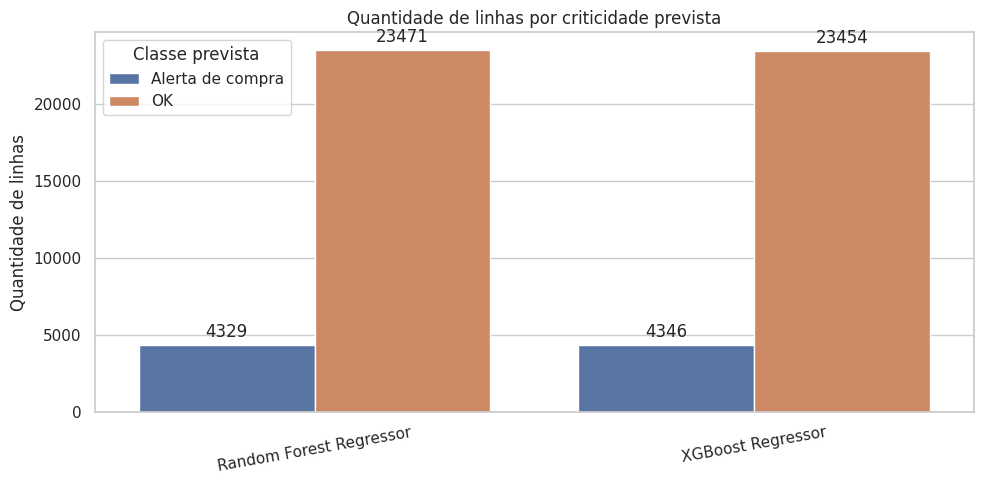

In [34]:
if logged_predictions.empty:
    display(pd.DataFrame({
        "aviso": [
            "Nao foi possivel mostrar exemplos de linhas porque os artefatos de predicao do MLflow nao estao acessiveis nesta execucao. "
            "Nenhuma previsao foi recalculada neste notebook."
        ]
    }))
else:
    prediction_class_counts = (
        logged_predictions.groupby(["model", "criticidade_predita"], as_index=False)
        .size()
        .rename(columns={"size": "quantidade"})
    )
    prediction_class_counts["percentual"] = (
        prediction_class_counts["quantidade"]
        / prediction_class_counts.groupby("model")["quantidade"].transform("sum")
        * 100
    )
    display(prediction_class_counts.sort_values(["model", "criticidade_predita"]).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=prediction_class_counts,
        x="model",
        y="quantidade",
        hue="criticidade_predita",
        ax=ax,
    )
    ax.set_title("Quantidade de linhas por criticidade prevista")
    ax.set_xlabel("")
    ax.set_ylabel("Quantidade de linhas")
    ax.tick_params(axis="x", rotation=10)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)
    ax.legend(title="Classe prevista")
    fig.tight_layout()
    plt.show()


In [35]:
example_columns = [
    "model",
    "ingredient_id",
    "date",
    "nome_ingrediente",
    "categoria",
    "unidade",
    "stock_position",
    "baseline_threshold",
    "cobertura_estoque_pct",
    "limiar_alerta_real_pct",
    "limiar_alerta_predito_pct",
    "limiar_critico_predito_pct",
    "criticidade_real",
    "criticidade_predita",
    "score_alerta_compra",
    "erro_limiar_alerta_pct",
]

if logged_predictions.empty:
    critical_examples = pd.DataFrame()
    non_critical_examples = pd.DataFrame()
else:
    available_columns = [column for column in example_columns if column in logged_predictions.columns]
    critical_mask = logged_predictions["criticidade_predita"].astype(str).str.contains("Alerta", case=False, na=False)
    critical_examples = (
        logged_predictions.loc[critical_mask, available_columns]
        .sort_values(["model", "score_alerta_compra"], ascending=[True, False])
        .groupby("model", as_index=False)
        .head(5)
        .reset_index(drop=True)
    )
    non_critical_examples = (
        logged_predictions.loc[~critical_mask, available_columns]
        .sort_values(["model", "score_alerta_compra"], ascending=[True, True])
        .groupby("model", as_index=False)
        .head(5)
        .reset_index(drop=True)
    )

print("Exemplos previstos como criticos / alerta de compra")
display(critical_examples)
print("Exemplos previstos como nao criticos / OK")
display(non_critical_examples)


Exemplos previstos como criticos / alerta de compra


,model,ingredient_id,date,nome_ingrediente,categoria,unidade,stock_position,baseline_threshold,cobertura_estoque_pct,limiar_alerta_real_pct,limiar_alerta_predito_pct,limiar_critico_predito_pct,criticidade_real,criticidade_predita,score_alerta_compra,erro_limiar_alerta_pct
0,Random Forest Regressor,ING0244,2026-01-04,ÓLEO DE SOJA,Óleos e Gorduras,L,0.0,7.370593,0.0,0.75,0.747925,0.597925,Alerta de compra,Alerta de compra,0.597925,-0.002075
1,Random Forest Regressor,ING0073,2026-01-09,POLVILHO AZEDO,"Grãos, Farinhas e Massas",KG,0.0,8.580532,0.0,0.75,0.747925,0.597925,Alerta de compra,Alerta de compra,0.597925,-0.002075
2,Random Forest Regressor,ING0244,2026-01-12,ÓLEO DE SOJA,Óleos e Gorduras,L,0.0,7.134274,0.0,0.75,0.747925,0.597925,Alerta de compra,Alerta de compra,0.597925,-0.002075
3,Random Forest Regressor,ING0073,2026-01-22,POLVILHO AZEDO,"Grãos, Farinhas e Massas",KG,0.0,9.598969,0.0,0.75,0.747925,0.597925,Alerta de compra,Alerta de compra,0.597925,-0.002075
4,Random Forest Regressor,ING0073,2026-02-13,POLVILHO AZEDO,"Grãos, Farinhas e Massas",KG,0.0,13.477710,0.0,0.75,0.747925,0.597925,Alerta de compra,Alerta de compra,0.597925,-0.002075
5,XGBoost Regressor,ING0074,2026-03-26,POLVILHO DOCE,"Grãos, Farinhas e Massas",KG,0.0,11.262178,0.0,0.75,0.746155,0.596155,Alerta de compra,Alerta de compra,0.596155,-0.003845
6,XGBoost Regressor,ING0074,2026-01-02,POLVILHO DOCE,"Grãos, Farinhas e Massas",KG,0.0,9.177539,0.0,0.75,0.744727,0.594727,Alerta de compra,Alerta de compra,0.594727,-0.005273
7,XGBoost Regressor,ING0074,2026-01-03,POLVILHO DOCE,"Grãos, Farinhas e Massas",KG,0.0,8.325778,0.0,0.75,0.743081,0.593081,Alerta de compra,Alerta de compra,0.593081,-0.006919
8,XGBoost Regressor,ING0244,2026-01-11,ÓLEO DE SOJA,Óleos e Gorduras,L,0.0,7.326270,0.0,0.75,0.741996,0.591996,Alerta de compra,Alerta de compra,0.591996,-0.008004
9,XGBoost Regressor,ING0244,2026-01-12,ÓLEO DE SOJA,Óleos e Gorduras,L,0.0,7.134274,0.0,0.75,0.740470,0.590470,Alerta de compra,Alerta de compra,0.590470,-0.009530


Exemplos previstos como nao criticos / OK


,model,ingredient_id,date,nome_ingrediente,categoria,unidade,stock_position,baseline_threshold,cobertura_estoque_pct,limiar_alerta_real_pct,limiar_alerta_predito_pct,limiar_critico_predito_pct,criticidade_real,criticidade_predita,score_alerta_compra,erro_limiar_alerta_pct
0,Random Forest Regressor,ING0234,2026-01-05,PIMENTA DO REINO,Temperos e Especiarias,KG,0.05,0.008898,1.0,0.250000,0.250033,0.100033,OK,OK,-0.899967,0.000033
1,Random Forest Regressor,ING0234,2026-01-06,PIMENTA DO REINO,Temperos e Especiarias,KG,0.05,0.009076,1.0,0.250000,0.250033,0.100033,OK,OK,-0.899967,0.000033
2,Random Forest Regressor,ING0234,2026-01-07,PIMENTA DO REINO,Temperos e Especiarias,KG,0.05,0.009285,1.0,0.250000,0.250033,0.100033,OK,OK,-0.899967,0.000033
3,Random Forest Regressor,ING0234,2026-01-08,PIMENTA DO REINO,Temperos e Especiarias,KG,0.05,0.009821,1.0,0.250000,0.250033,0.100033,OK,OK,-0.899967,0.000033
4,Random Forest Regressor,ING0234,2026-01-09,PIMENTA DO REINO,Temperos e Especiarias,KG,0.05,0.009733,1.0,0.250000,0.250033,0.100033,OK,OK,-0.899967,0.000033
5,XGBoost Regressor,ING0066,2026-04-11,FARINHA DE TRIGO,"Grãos, Farinhas e Massas",KG,284.54,118.243139,1.0,0.285714,0.255901,0.105901,OK,OK,-0.894099,-0.029813
6,XGBoost Regressor,ING0066,2026-04-14,FARINHA DE TRIGO,"Grãos, Farinhas e Massas",KG,284.54,118.529699,1.0,0.285714,0.256355,0.106355,OK,OK,-0.893645,-0.029360
7,XGBoost Regressor,ING0066,2026-04-15,FARINHA DE TRIGO,"Grãos, Farinhas e Massas",KG,284.54,119.122545,1.0,0.285714,0.256355,0.106355,OK,OK,-0.893645,-0.029360
8,XGBoost Regressor,ING0066,2026-04-09,FARINHA DE TRIGO,"Grãos, Farinhas e Massas",KG,666.35,108.255137,1.0,0.285714,0.256594,0.106594,OK,OK,-0.893406,-0.029121
9,XGBoost Regressor,ING0066,2026-01-03,FARINHA DE TRIGO,"Grãos, Farinhas e Massas",KG,284.54,81.925691,1.0,0.250000,0.256628,0.106628,OK,OK,-0.893372,0.006628


## Avaliacao estatistica disponivel

Com apenas dois modelos finais, Friedman e Nemenyi nao se aplicam. Como os notebooks expuseram os RMSEs por fold, fazemos t pareado e Wilcoxon sobre `validation_rmse` pareado por fold, com a ressalva de que ha apenas 3 folds.


In [36]:
stat_rows = []
fold_pivot = fold_metrics.pivot(index="fold", columns="model", values="validation_rmse")
models = list(fold_pivot.columns)
if len(models) == 2:
    a, b = models
    paired = fold_pivot[[a, b]].dropna()
    diff = paired[a] - paired[b]
    t_stat, t_p = stats.ttest_rel(paired[a], paired[b])
    try:
        w_stat, w_p = stats.wilcoxon(paired[a], paired[b], zero_method="wilcox")
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    stat_rows.extend(
        [
            {
                "test": "paired_t_test",
                "metric": "validation_rmse_by_fold",
                "model_a": a,
                "model_b": b,
                "n_pairs": len(paired),
                "statistic": t_stat,
                "p_value": t_p,
                "mean_diff_a_minus_b": diff.mean(),
                "note": "baixo poder estatistico: apenas 3 folds disponiveis nos outputs",
            },
            {
                "test": "wilcoxon_signed_rank",
                "metric": "validation_rmse_by_fold",
                "model_a": a,
                "model_b": b,
                "n_pairs": len(paired),
                "statistic": w_stat,
                "p_value": w_p,
                "mean_diff_a_minus_b": diff.mean(),
                "note": "baixo poder estatistico: apenas 3 folds disponiveis nos outputs",
            },
        ]
    )

stat_rows.extend(
    [
        {"test": "friedman", "metric": "validation_rmse_by_fold", "model_a": "all", "model_b": "all", "n_pairs": len(fold_pivot), "statistic": np.nan, "p_value": np.nan, "mean_diff_a_minus_b": np.nan, "note": "nao_aplicavel: requer pelo menos 3 modelos"},
        {"test": "nemenyi_posthoc", "metric": "validation_rmse_by_fold", "model_a": "all", "model_b": "all", "n_pairs": len(fold_pivot), "statistic": np.nan, "p_value": np.nan, "mean_diff_a_minus_b": np.nan, "note": "nao_aplicavel: pos-hoc apos Friedman com pelo menos 3 modelos"},
    ]
)
statistical_tests = pd.DataFrame(stat_rows)
statistical_tests


,test,metric,model_a,model_b,n_pairs,statistic,p_value,mean_diff_a_minus_b,note
0,paired_t_test,validation_rmse_by_fold,Random Forest Regressor,XGBoost Regressor,3,-2.171672,0.16202,-0.001018,baixo poder estatistico: apenas 3 folds disponiveis nos outputs
1,wilcoxon_signed_rank,validation_rmse_by_fold,Random Forest Regressor,XGBoost Regressor,3,0.000000,0.25000,-0.001018,baixo poder estatistico: apenas 3 folds disponiveis nos outputs
2,friedman,validation_rmse_by_fold,all,all,3,NaN,NaN,NaN,nao_aplicavel: requer pelo menos 3 modelos
3,nemenyi_posthoc,validation_rmse_by_fold,all,all,3,NaN,NaN,NaN,nao_aplicavel: pos-hoc apos Friedman com pelo menos 3 modelos


## Ranking multicriterio com dados disponiveis

O ranking abaixo usa apenas criterios materializados nos outputs: desempenho, generalizacao, robustez por RMSE/MAE e proxy simples de complexidade. Tempo, recursos e interpretabilidade detalhada ficam indisponiveis porque nao foram medidos nos notebooks finais.

Importante: os pontos sao relativos ao conjunto comparado. Como ha apenas dois modelos, o primeiro colocado em um criterio recebe `1.0` e o segundo recebe `0.5`; isso evita interpretar `0.0` como uma metrica absoluta ruim.


In [37]:
def _rank_points_from_rank(rank: pd.Series) -> pd.Series:
    n = len(rank)
    if n == 0:
        return pd.Series(dtype=float)
    return (n + 1 - rank.astype(float)) / n


def _average_rank(rank_parts: list[pd.Series], weights: list[float] | None = None) -> pd.Series:
    ranks = pd.concat(rank_parts, axis=1)
    if weights is None:
        return ranks.mean(axis=1)
    weight_array = np.asarray(weights, dtype=float)
    weight_array = weight_array / weight_array.sum()
    return ranks.mul(weight_array, axis=1).sum(axis=1)

rank_base = (
    performance[["model", "test_rmse", "test_mae", "test_r2", "rmse_over_mae_test"]]
    .merge(
        stability[["model", "mean", "std", "coefficient_variation"]].rename(
            columns={
                "mean": "cv_validation_rmse_mean",
                "std": "cv_validation_rmse_std",
                "coefficient_variation": "cv_validation_rmse_cv",
            }
        ),
        on="model",
    )
    .merge(complexity[["model", "complexity_proxy_estimators_x_depth"]], on="model")
)

ranking_scores = rank_base[["model"]].copy()
ranking_scores["rank_precisao"] = _average_rank([
    rank_base["test_rmse"].rank(method="min", ascending=True),
    rank_base["test_mae"].rank(method="min", ascending=True),
    rank_base["test_r2"].rank(method="min", ascending=False),
])
ranking_scores["rank_generalizacao"] = _average_rank([
    rank_base["cv_validation_rmse_mean"].rank(method="min", ascending=True),
    rank_base["cv_validation_rmse_std"].rank(method="min", ascending=True),
    rank_base["cv_validation_rmse_cv"].rank(method="min", ascending=True),
], weights=[0.60, 0.20, 0.20])
ranking_scores["rank_robustez"] = rank_base["rmse_over_mae_test"].rank(method="min", ascending=True)
ranking_scores["rank_complexidade"] = rank_base["complexity_proxy_estimators_x_depth"].rank(method="min", ascending=True)

for criterion in ["precisao", "generalizacao", "robustez", "complexidade"]:
    ranking_scores[f"pontos_{criterion}"] = _rank_points_from_rank(ranking_scores[f"rank_{criterion}"])

ranking_scores["interpretabilidade"] = np.nan
ranking_scores["tempo_execucao"] = np.nan
ranking_scores["consumo_recursos"] = np.nan
ranking_scores["overall_available_score"] = ranking_scores[[
    "pontos_precisao",
    "pontos_generalizacao",
    "pontos_robustez",
    "pontos_complexidade",
]].mean(axis=1)

ranking_overall = ranking_scores.sort_values("overall_available_score", ascending=False).reset_index(drop=True)
ranking_overall.insert(0, "rank", ranking_overall.index + 1)

ranking_by_criterion = []
for criterion in ["precisao", "generalizacao", "robustez", "complexidade"]:
    ordered = ranking_scores[["model", f"rank_{criterion}", f"pontos_{criterion}"]].sort_values(
        [f"rank_{criterion}", "model"], ascending=[True, True]
    ).reset_index(drop=True)
    for _, row in ordered.iterrows():
        ranking_by_criterion.append({
            "criterion": criterion,
            "rank": row[f"rank_{criterion}"],
            "model": row["model"],
            "points": row[f"pontos_{criterion}"],
        })
ranking_by_criterion = pd.DataFrame(ranking_by_criterion)

ranking_detalhado = rank_base.merge(ranking_scores, on="model", how="left")

# Pontos sao relativos aos modelos comparados: com 2 modelos, 1o lugar = 1.0 e 2o lugar = 0.5.
# Eles nao sao metricas absolutas de qualidade, precisao percentual, robustez real ou complexidade real.
display(ranking_overall)
display(ranking_by_criterion)
display(ranking_detalhado)


,rank,model,rank_precisao,rank_generalizacao,rank_robustez,rank_complexidade,pontos_precisao,pontos_generalizacao,pontos_robustez,pontos_complexidade,interpretabilidade,tempo_execucao,consumo_recursos,overall_available_score
0,1,XGBoost Regressor,2.0,1.6,1.0,1.0,0.5,0.7,1.0,1.0,NaN,NaN,NaN,0.8
1,2,Random Forest Regressor,1.0,1.4,2.0,2.0,1.0,0.8,0.5,0.5,NaN,NaN,NaN,0.7


,criterion,rank,model,points
0,precisao,1.0,Random Forest Regressor,1.0
1,precisao,2.0,XGBoost Regressor,0.5
2,generalizacao,1.4,Random Forest Regressor,0.8
3,generalizacao,1.6,XGBoost Regressor,0.7
4,robustez,1.0,XGBoost Regressor,1.0
5,robustez,2.0,Random Forest Regressor,0.5
6,complexidade,1.0,XGBoost Regressor,1.0
7,complexidade,2.0,Random Forest Regressor,0.5


,model,test_rmse,test_mae,test_r2,rmse_over_mae_test,cv_validation_rmse_mean,cv_validation_rmse_std,cv_validation_rmse_cv,complexity_proxy_estimators_x_depth,rank_precisao,rank_generalizacao,rank_robustez,rank_complexidade,pontos_precisao,pontos_generalizacao,pontos_robustez,pontos_complexidade,interpretabilidade,tempo_execucao,consumo_recursos,overall_available_score
0,Random Forest Regressor,0.045343,0.034145,0.801977,1.327954,0.053637,0.002765,0.051545,1680,1.0,1.4,2.0,2.0,1.0,0.8,0.5,0.5,NaN,NaN,NaN,0.7
1,XGBoost Regressor,0.046962,0.035402,0.787586,1.326535,0.054655,0.002616,0.047870,1040,2.0,1.6,1.0,1.0,0.5,0.7,1.0,1.0,NaN,NaN,NaN,0.8


## Graficos comparativos


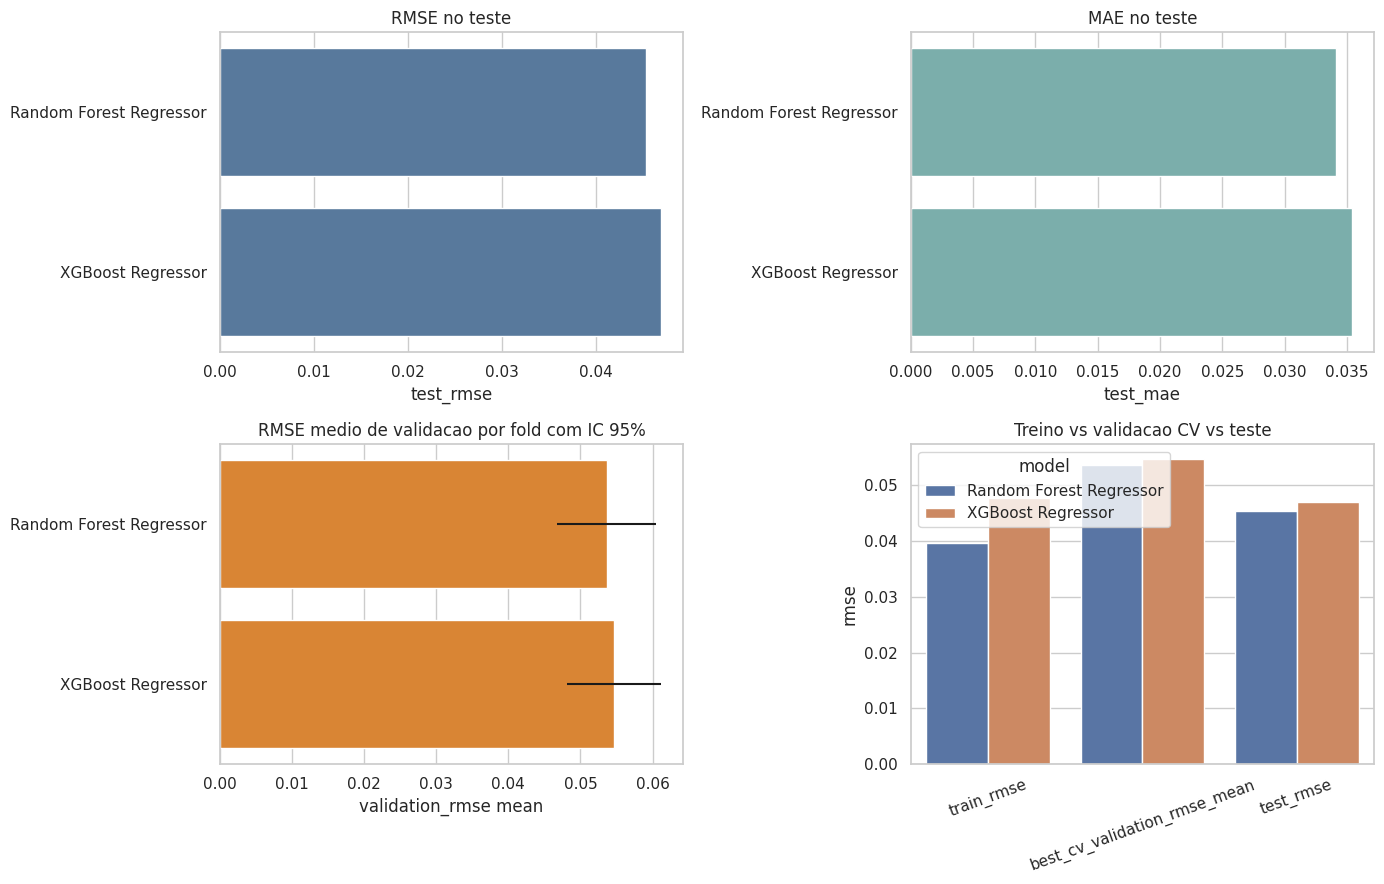

In [38]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.barplot(data=performance, y="model", x="test_rmse", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("RMSE no teste")
axes[0, 0].set_ylabel("")

sns.barplot(data=performance, y="model", x="test_mae", ax=axes[0, 1], color="#72B7B2")
axes[0, 1].set_title("MAE no teste")
axes[0, 1].set_ylabel("")

sns.barplot(data=stability, y="model", x="mean", xerr=stability["ci95_margin"], ax=axes[1, 0], color="#F58518")
axes[1, 0].set_title("RMSE medio de validacao por fold com IC 95%")
axes[1, 0].set_xlabel("validation_rmse mean")
axes[1, 0].set_ylabel("")

plot_overfit = overfit.melt(id_vars="model", value_vars=["train_rmse", "best_cv_validation_rmse_mean", "test_rmse"], var_name="split_metric", value_name="rmse")
sns.barplot(data=plot_overfit, x="split_metric", y="rmse", hue="model", ax=axes[1, 1])
axes[1, 1].set_title("Treino vs validacao CV vs teste")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()


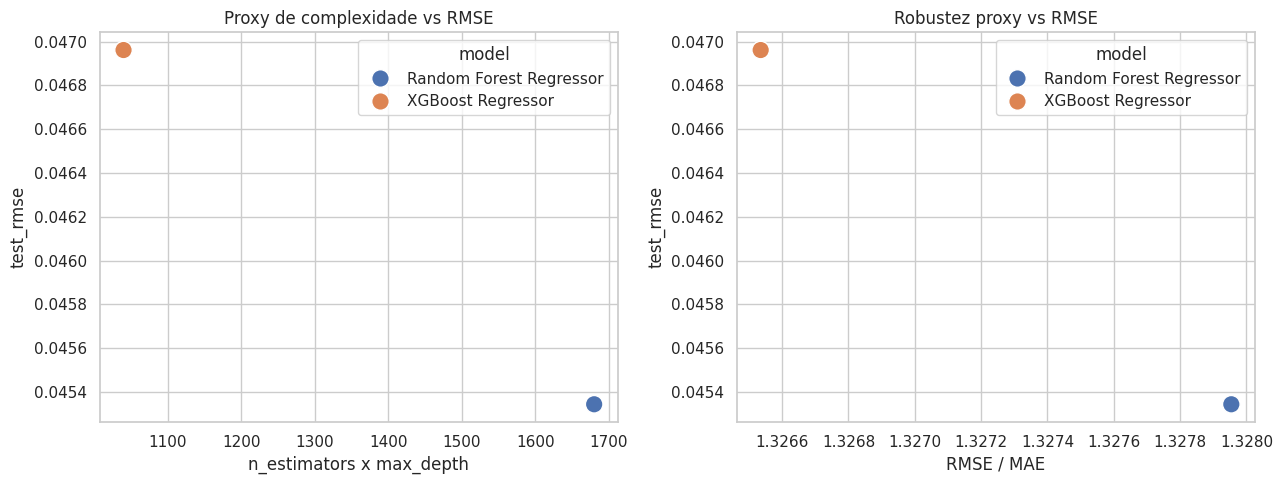

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=rank_base, x="complexity_proxy_estimators_x_depth", y="test_rmse", hue="model", s=160, ax=axes[0])
axes[0].set_title("Proxy de complexidade vs RMSE")
axes[0].set_xlabel("n_estimators x max_depth")
axes[0].set_ylabel("test_rmse")

sns.scatterplot(data=robustness, x="rmse_over_mae_test", y="test_rmse", hue="model", s=160, ax=axes[1])
axes[1].set_title("Robustez proxy vs RMSE")
axes[1].set_xlabel("RMSE / MAE")
axes[1].set_ylabel("test_rmse")

fig.tight_layout()
plt.show()


## Conclusao consolidada


In [40]:
best_raw = performance.sort_values(["test_rmse", "test_mae"]).iloc[0]["model"]
best_generalization = stability.sort_values(["mean", "coefficient_variation"]).iloc[0]["model"]
best_robust = robustness.sort_values("rmse_over_mae_test").iloc[0]["model"]
best_complexity_proxy = complexity.sort_values("complexity_proxy_estimators_x_depth").iloc[0]["model"]
recommended = ranking_overall.iloc[0]["model"]

conclusion = pd.DataFrame(
    [
        {"pergunta": "Melhor modelo em desempenho bruto", "modelo": best_raw, "criterio_usado": "menor test_rmse e test_mae disponiveis"},
        {"pergunta": "Melhor modelo em generalizacao", "modelo": best_generalization, "criterio_usado": "menor validation_rmse medio nos folds ja executados"},
        {"pergunta": "Melhor custo-beneficio disponivel", "modelo": recommended, "criterio_usado": "ranking geral com desempenho, generalizacao, robustez proxy e complexidade proxy; tempo/CPU/RAM nao foram medidos nos outputs"},
        {"pergunta": "Modelo mais robusto", "modelo": best_robust, "criterio_usado": "menor relacao RMSE/MAE no teste"},
        {"pergunta": "Modelo mais simples pelo proxy disponivel", "modelo": best_complexity_proxy, "criterio_usado": "menor n_estimators x max_depth configurado"},
        {"pergunta": "Modelo mais interpretavel", "modelo": "indeterminado", "criterio_usado": "interpretabilidade detalhada nao foi materializada nos notebooks 05/06"},
        {"pergunta": "Modelo recomendado para producao", "modelo": recommended, "criterio_usado": "melhor ranking geral com os dados atualmente consolidados"},
    ]
)
conclusion


,pergunta,modelo,criterio_usado
0,Melhor modelo em desempenho bruto,Random Forest Regressor,menor test_rmse e test_mae disponiveis
1,Melhor modelo em generalizacao,Random Forest Regressor,menor validation_rmse medio nos folds ja executados
2,Melhor custo-beneficio disponivel,XGBoost Regressor,"ranking geral com desempenho, generalizacao, robustez proxy e complexidade proxy; tempo/CPU/RAM nao foram medidos nos outputs"
3,Modelo mais robusto,XGBoost Regressor,menor relacao RMSE/MAE no teste
4,Modelo mais simples pelo proxy disponivel,XGBoost Regressor,menor n_estimators x max_depth configurado
5,Modelo mais interpretavel,indeterminado,interpretabilidade detalhada nao foi materializada nos notebooks 05/06
6,Modelo recomendado para producao,XGBoost Regressor,melhor ranking geral com os dados atualmente consolidados
